# Employee Attrition Analytics

Employee attrition is one of the biggest challenges for organizations because replacing employees is expensive and affects productivity.

The objective of this project is to analyze employee data, identify the factors influencing attrition, and provide data-driven recommendations to improve employee retention.

# Project Objectives

- Understand the employee dataset
- Clean and prepare the data
- Perform Exploratory Data Analysis (EDA)
- Identify factors affecting employee attrition
- Create visualizations
- Generate business insights
- Build an interactive Tableau dashboard

# Import Libraries

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Better chart style
sns.set_theme(style="whitegrid")

# Load Dataset

In [5]:
# Load the dataset
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Data Inspection

In [7]:
df.shape

(1470, 35)

In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15


# observations
- The dataset contains 1,470 employee records and 35 columns.
- No missing values were observed in the dataset.
- Both numerical and categorical features are present.
- The dataset appears clean and suitable for further analysis.


In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Duplicate Value Analysis

In [12]:

df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Length: 1470, dtype: bool

In [14]:
df["Department"].unique()

<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

In [15]:
df["Department"].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

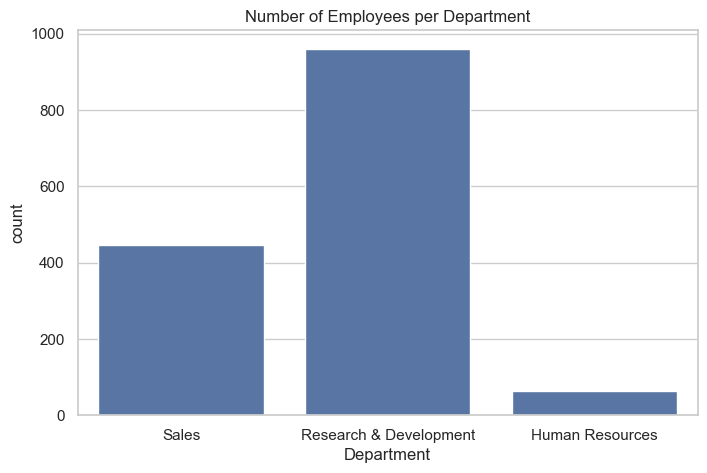

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x="Department", data=df)
plt.title("Number of Employees per Department")
plt.show()

Observations

- The company has three departments.
- Research & Development has the largest workforce.
- Human Resources has the fewest employees.
- Workforce distribution is not uniform across departments.

# Target Variable Analysis - Attrition

In [17]:
df["Attrition"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [18]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [20]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [23]:
(df["Attrition"].value_counts(normalize=True) * 100).round (2)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

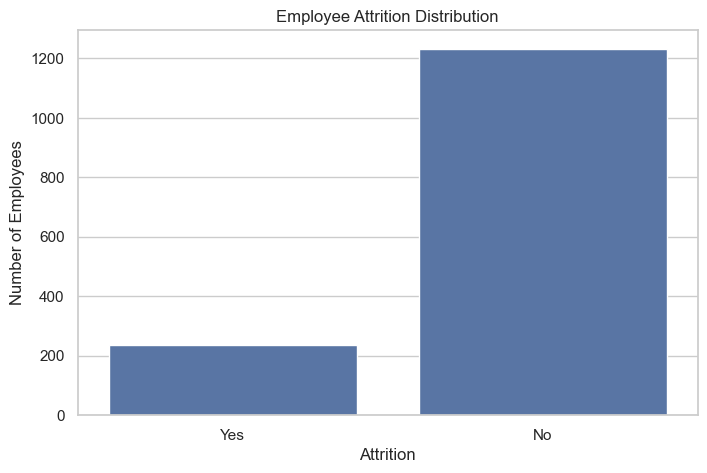

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

# Overtime Analysis

In [26]:
df["OverTime"].value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

In [32]:
pd.crosstab(df["OverTime"], df["Attrition"])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


<Axes: xlabel='Department', ylabel='count'>

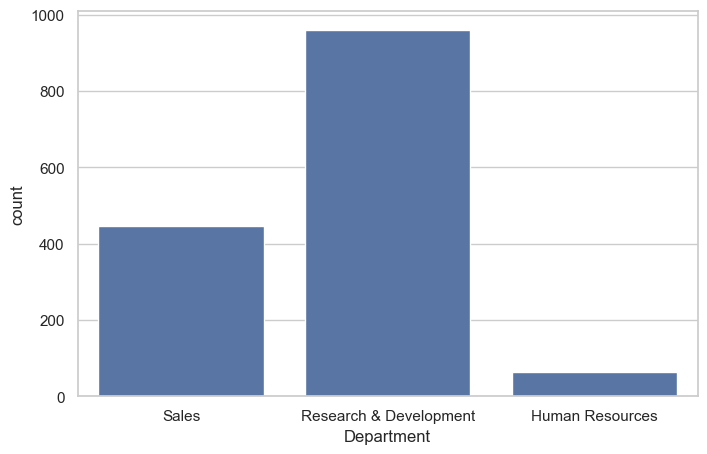

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x="Department", data=df)

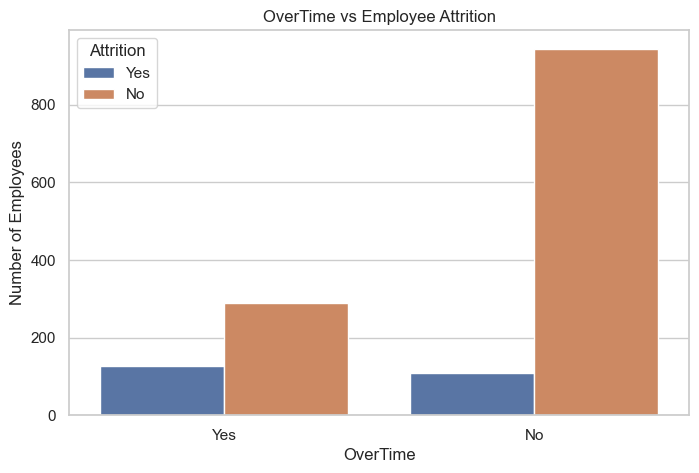

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x = "OverTime",
    hue = "Attrition",
)
plt.title("OverTime vs Employee Attrition")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()

# Observations:
Most employees do not work overtime.
Employees who work overtime appear to have a higher proportion of attrition.
Overtime could be an important factor influencing employee turnover.

# Monthly Income vs Attrition

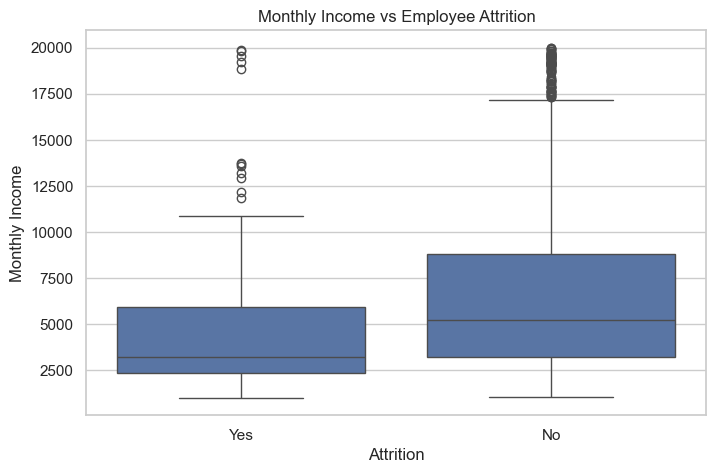

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x = "Attrition",
    y = "MonthlyIncome",
)
plt.title("Monthly Income vs Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

# Observations:
- Employees who left the company generally have a lower median monthly income than those who stayed. 
- The salary distribution for employees who stayed is higher overall. 
- Several high-income outliers exist in both groups, indicating that salary alone does not explain attrition. 
- Monthly income appears to be associated with employee attrition and should be investigated further alongside other factors.

In [39]:
df["JobSatisfaction"].value_counts().sort_index()

JobSatisfaction
1    289
2    280
3    442
4    459
Name: count, dtype: int64

In [40]:
pd.crosstab(df["JobSatisfaction"], df["Attrition"])

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


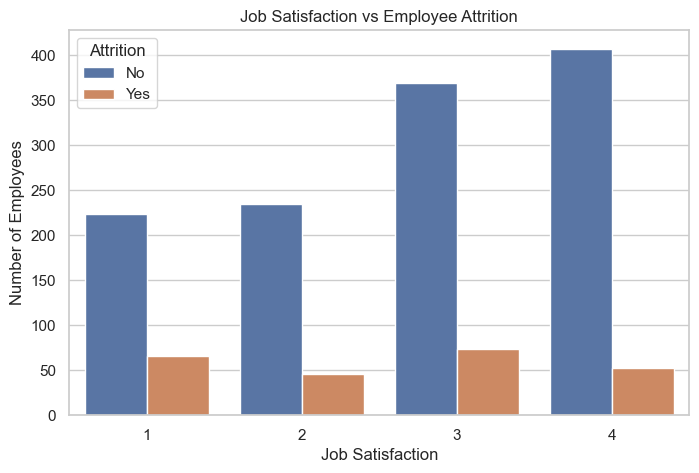

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")
plt.title("Job Satisfaction vs Employee Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")
plt.show()

# Calculating the percentage to understand which satisfaction has the highest number of employees leaving.
# The result for the above can't be concluded just from the count plot graph.
# Eg. According to the naked eye satisfaction level 4 has the highest number og employees leaving but at the same time it could be because it has the most number of employees.

In [44]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


# Department vs Attrition

In [47]:
df["Department"].value_counts()


Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

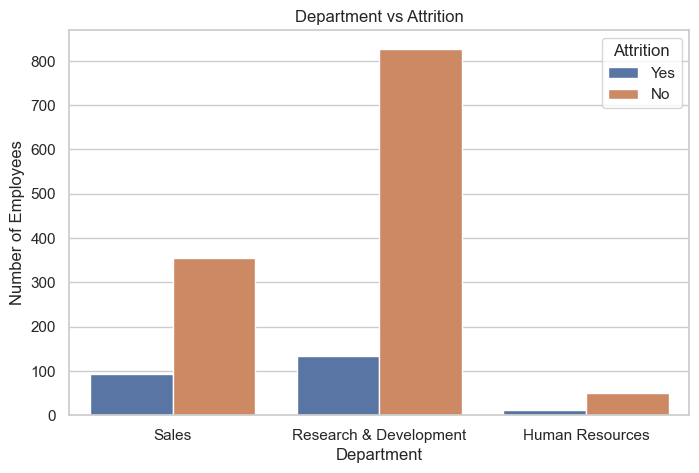

In [53]:
plt.figure(figsize=(8,5))
sns.countplot(
    data = df,
    x="Department", hue = "Attrition")
plt.title("Department vs Attrition")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

In [50]:
pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
    ) * 100


Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


# Since the departments have different numbers of employees. Comparing raw counts could lead to misleading conclusion.
# Sales department has the highest attrition percentage.

# Correlation Analysis
# Attrition column(Categorical data type) needs to be converted to Attrition_Numeric(Attrition with numerical data type, (0,1)) since correlation can be performed only with numerical data type
# Created a new column instead of changing the original since the original is helpful when we need to visualize.

In [54]:
df["Attrition_Numeric"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

In [55]:
df[["Attrition", "Attrition_Numeric"]].head()

,Attrition,Attrition_Numeric
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


# Only considers columns with numeric data types

In [56]:
correlation = df.corr(numeric_only=True)

In [57]:
correlation

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Numeric
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089,-0.159205
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363,-0.056652
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406,0.077924
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065,-0.031373
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197,-0.010577
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999,-0.103369
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123,-0.006846
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976,-0.130016
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281,-0.169105


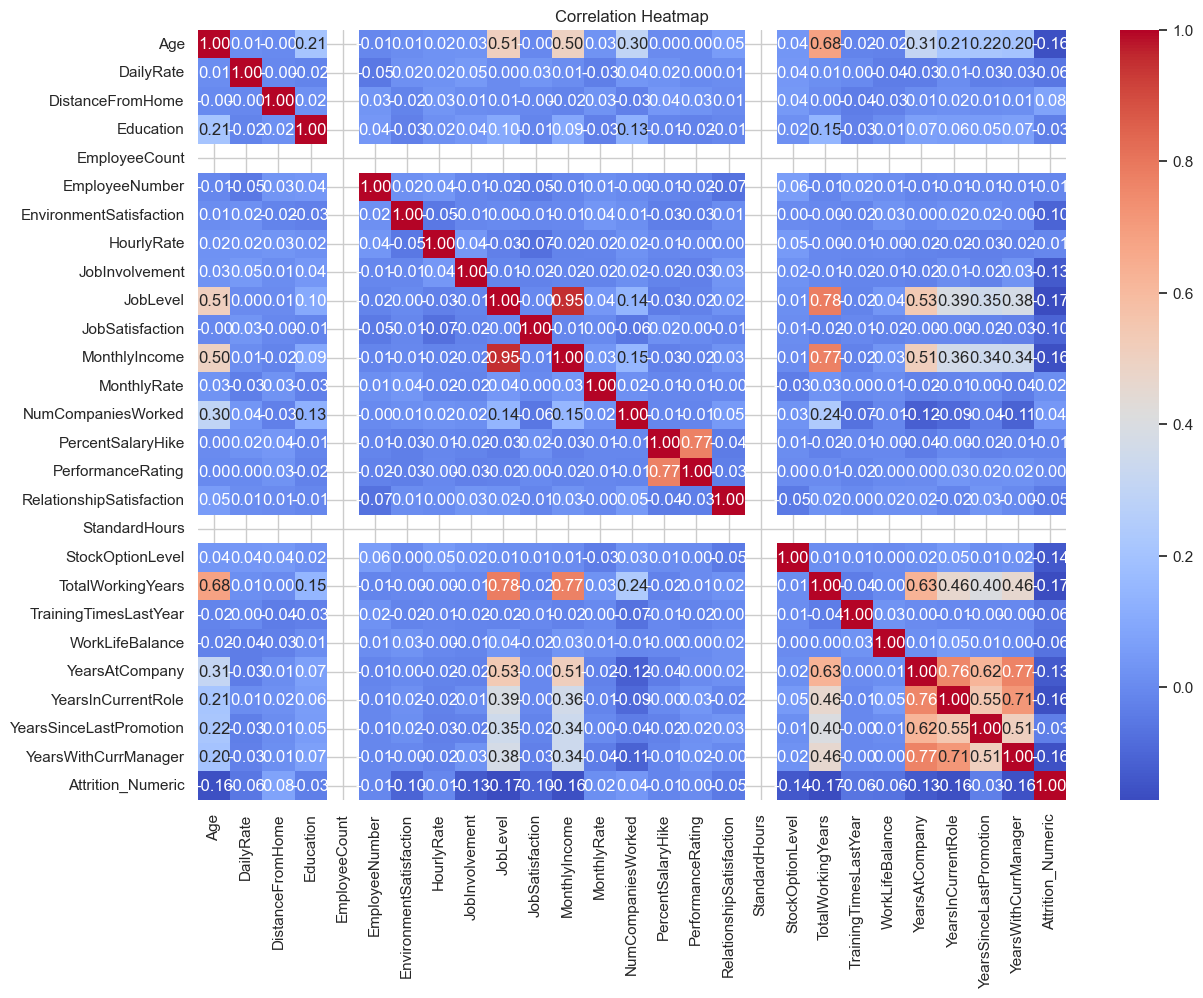

In [59]:
plt.figure(figsize=(14,10))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Heatmap")
plt.show()

# Extract the Attrition Correlations

# Variables related to Employee Attrition

In [60]:
correlation["Attrition_Numeric"]

Age                        -0.159205
DailyRate                  -0.056652
DistanceFromHome            0.077924
Education                  -0.031373
EmployeeCount                    NaN
EmployeeNumber             -0.010577
EnvironmentSatisfaction    -0.103369
HourlyRate                 -0.006846
JobInvolvement             -0.130016
JobLevel                   -0.169105
JobSatisfaction            -0.103481
MonthlyIncome              -0.159840
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
PercentSalaryHike          -0.013478
PerformanceRating           0.002889
RelationshipSatisfaction   -0.045872
StandardHours                    NaN
StockOptionLevel           -0.137145
TotalWorkingYears          -0.171063
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
YearsAtCompany             -0.134392
YearsInCurrentRole         -0.160545
YearsSinceLastPromotion    -0.033019
YearsWithCurrManager       -0.156199
Attrition_Numeric           1.000000
N

# Sorting the correlations(sorts lowest correlation to highest) helped identify the variables most strongly associated with employee attrition, allowing me to prioritize which factors to investigate further.

In [61]:
correlation["Attrition_Numeric"].sort_values()

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
Attrition_Numeric           1.000000
EmployeeCount                    NaN
StandardHours                    NaN
N

# KPI Calculations

# KPI 1

In [62]:
df.shape[0]

1470

# KPI 2
# Employees who left

In [63]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

# KPI 3
# Attrition Rate:

In [64]:
attrition_rate = df["Attrition"].value_counts(normalize=True)["Yes"] * 100
print (f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


# KPI 4
# Average Monthly Income

In [65]:
average_income = df["MonthlyIncome"].mean()
print(f"Average Income: Rs.{average_income:,.2f}")

Average Income: Rs.6,502.93
